In [1]:
import sys
from pathlib import Path

# add src directory to python path
sys.path.append(str(Path.cwd().parent / "src"))

# data exploration libraries
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# pipline tools
from data import download
from pre_process import (
    clean, 
    name_fix, 
    elo, 
    feature
)

### Phase 01 : import from kaggle

In [2]:
csv_file = download.pull_data()

In [3]:
raw_file = pd.read_csv(csv_file)
raw_file.head(5)

,Tournament,Date,Series,Court,Surface,Round,Best of,Player_1,Player_2,Winner,Rank_1,Rank_2,Pts_1,Pts_2,Odd_1,Odd_2,Score
0,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Arthurs W.,Gambill J.M.,Gambill J.M.,105,58,-1,-1,-1.0,-1.0,6-3 6-7 4-6
1,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Balcells J.,Henman T.,Henman T.,218,11,-1,-1,-1.0,-1.0,4-6 6-7
2,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Clement A.,Enqvist T.,Enqvist T.,56,5,-1,-1,-1.0,-1.0,3-6 3-6
3,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Dosedel S.,Ljubicic I.,Dosedel S.,63,77,-1,-1,-1.0,-1.0,6-4 6-2
4,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Draper S.,Norman M.,Norman M.,155,15,-1,-1,-1.0,-1.0,4-6 4-6


### Phase 02 : explore data

Sort data and Add `Year` columns for better visualization in future

In [4]:
df = raw_file.copy()

df = clean.sort_data(df)
df = clean.seprate_year_column(df)

General status

In [5]:
print(df.shape)

(68353, 18)


In [6]:
print(df.dtypes)

Tournament            object
Date          datetime64[ns]
Series                object
Court                 object
Surface               object
Round                 object
Best of                int64
Player_1              object
Player_2              object
Winner                object
Rank_1                 int64
Rank_2                 int64
Pts_1                  int64
Pts_2                  int64
Odd_1                float64
Odd_2                float64
Score                 object
Year                   int32
dtype: object


Categorical columns analysis

In [7]:
cat_cols = ["Court", "Surface"]

for col in cat_cols:
    vc = df[col].value_counts(dropna=False)
    print(f"\n=== {col} ({df[col].nunique()} unique) ===")
    print(pd.DataFrame({"count": vc, "pct": (vc / len(df) * 100).round(2)}))


=== Court (2 unique) ===
         count    pct
Court                
Outdoor  56332  82.41
Indoor   12021  17.59

=== Surface (4 unique) ===
         count    pct
Surface              
Hard     36836  53.89
Clay     22152  32.41
Grass     7733  11.31
Carpet    1632   2.39


In [8]:
tournament_and_series_cols = ["Tournament", "Series"]

for col in tournament_and_series_cols:
    vc = df[col].value_counts(dropna=False)
    print(f"\n=== {col} ({df[col].nunique()} unique) ===")
    print(pd.DataFrame({"count": vc, "pct": (vc / len(df) * 100).round(2)}))


=== Tournament (268 unique) ===
                      count   pct
Tournament                       
French Open            3289  4.81
Australian Open        3275  4.79
Wimbledon              3183  4.66
US Open                3124  4.57
BNP Paribas Open       1555  2.27
...                     ...   ...
Melbourne Summer Set     25  0.04
Zhuhai Open              25  0.04
LA Tennis Open           25  0.04
Korea Open               24  0.04
Gijon Open               24  0.04

[268 rows x 2 columns]

=== Series (8 unique) ===
                    count    pct
Series                          
ATP250              18243  26.69
Grand Slam          12871  18.83
International       11752  17.19
Masters 1000         9644  14.11
ATP500               6807   9.96
Masters              5029   7.36
International Gold   3620   5.30
Masters Cup           387   0.57


In [9]:
best_of_and_round_cols = ["Best of", "Round"]

for col in best_of_and_round_cols:
    vc = df[col].value_counts(dropna=False)
    print(f"\n=== {col} ({df[col].nunique()} unique) ===")
    print(pd.DataFrame({"count": vc, "pct": (vc / len(df) * 100).round(2)}))


=== Best of (2 unique) ===
         count    pct
Best of              
3        55408  81.06
5        12945  18.94

=== Round (8 unique) ===
               count    pct
Round                      
1st Round      31290  45.78
2nd Round      19079  27.91
Quarterfinals   6466   9.46
3rd Round       4829   7.06
Semifinals      3306   4.84
The Final       1679   2.46
4th Round       1278   1.87
Round Robin      426   0.62


Analyze Games number & Surface types in different years

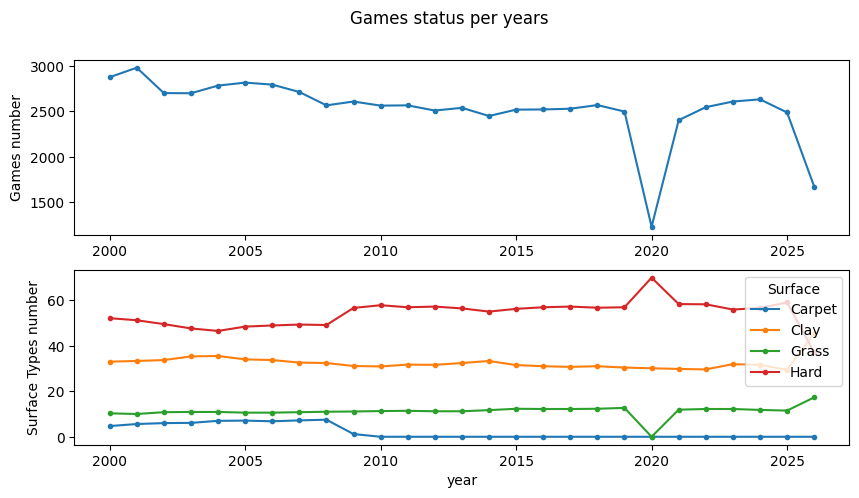

In [10]:
# extract data

per_year = df.groupby("Year").size().rename("matches")
surface_year = (
    pd.crosstab(df["Year"], df["Surface"], normalize="index")
    .mul(100).round(1)
)

# plot extracted data

fig, (ax1, ax2) = plt.subplots(2,1, figsize=(10, 5), dpi=100)

fig.suptitle('Games status per years')

ax1.plot(per_year, '.-')
ax1.set_ylabel('Games number')

surface_year.plot(ax=ax2, style=".-", legend=True)
ax2.set_ylabel('Surface Types number')
ax2.set_xlabel('year')

plt.show()

Analyse `Best of` parameter in different years

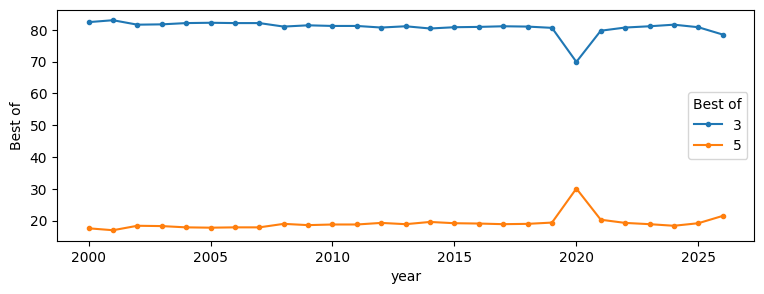

In [11]:
fig, ax = plt.subplots(figsize=(9, 3), dpi=100)

best_of_per_year = (
    pd.crosstab(df["Year"], df["Best of"], normalize="index")
    .mul(100).round(1)
)

best_of_per_year.plot(ax=ax, style='.-')
ax.set_ylabel('Best of')
ax.set_xlabel('year')

plt.show()

Analyse `rank`, `pts`, `odd` and `best of` distribution

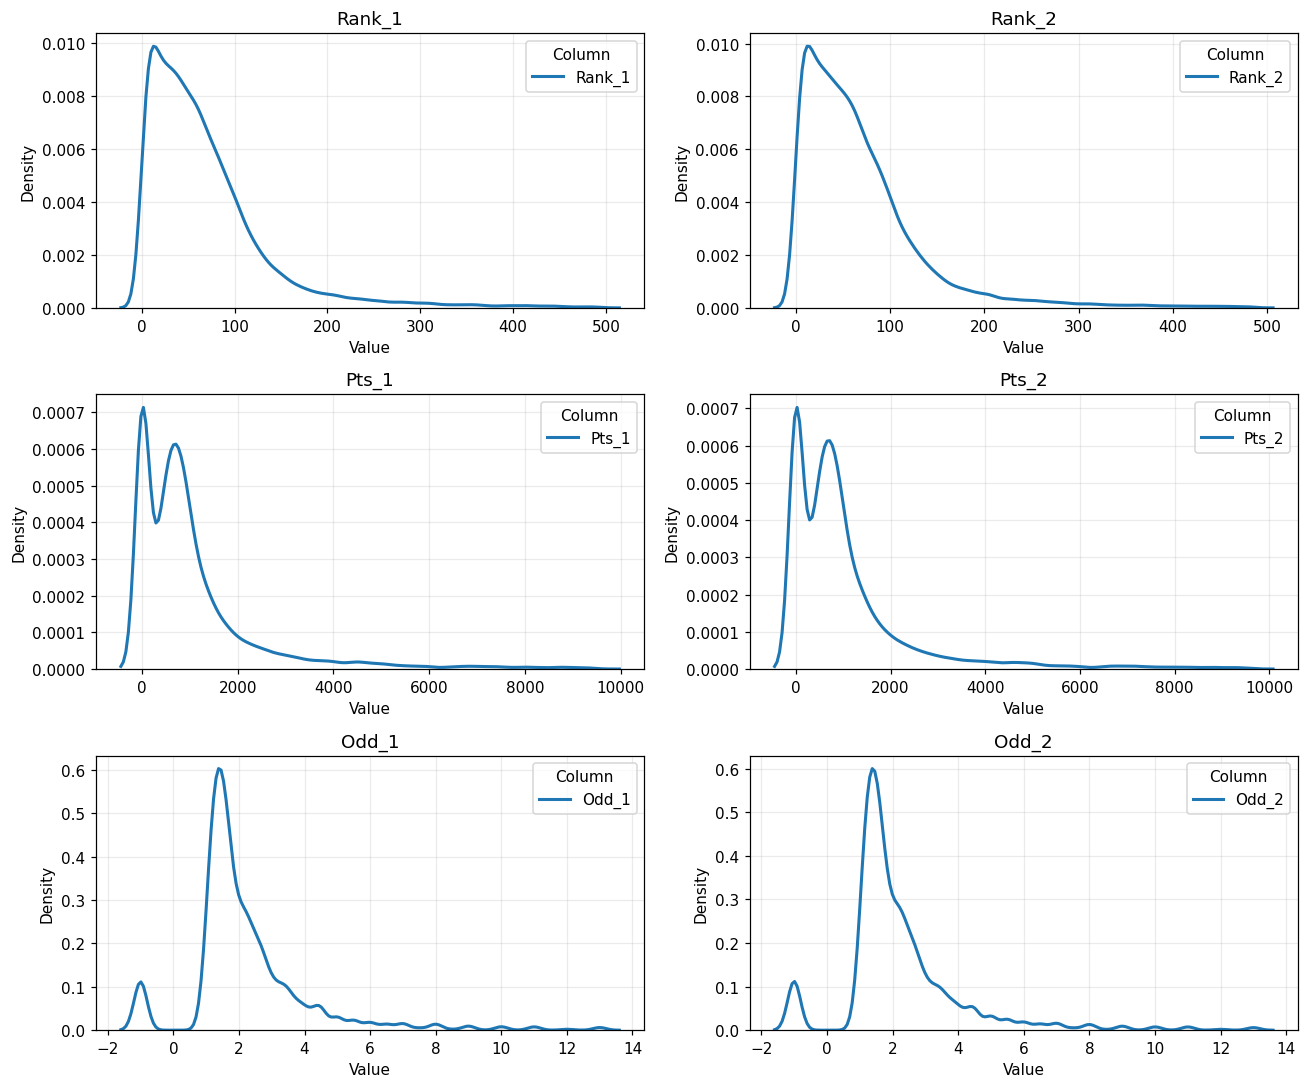

In [12]:
index_cols = ["Rank_1", "Rank_2", "Pts_1", "Pts_2", "Odd_1", "Odd_2"]

fig, axes = plt.subplots(3, 2, figsize=(12, 10), dpi=110)

for ax, col in zip(axes.ravel(), index_cols):
    s = pd.to_numeric(df[col], errors="coerce").dropna()
    s = s[s <= s.quantile(0.99)]
    sns.kdeplot(s, ax=ax, label=col, linewidth=2)

    ax.set_title(col)
    ax.set_xlabel("Value")
    ax.set_ylabel("Density")
    ax.legend(title="Column")
    ax.grid(alpha=0.25)

fig.tight_layout()
plt.show()


Analyse invalid Rank/Pts/Odd instances

In [13]:
rows = []
for c in index_cols:
    s = pd.to_numeric(df[c], errors="coerce")
    n = len(s)

    is_nan      = s.isna()
    is_minus1   = s.eq(-1)
    is_negative = s.lt(0)
    is_zero     = s.eq(0)

    if c.startswith("Odd"):
        invalid = is_nan | s.le(1)
    elif c.startswith("Rank"):
        invalid = is_nan | s.lt(1)
    else:
        invalid = is_nan | s.lt(0)

    rows.append({
        "column": c,
        "n": n,
        "nan": int(is_nan.sum()),
        "minus_1": int(is_minus1.sum()),
        "negative": int(is_negative.sum()),
        "zero": int(is_zero.sum()),
        "invalid": int(invalid.sum()),
        "invalid_%": round(invalid.mean() * 100, 2),
    })

report = pd.DataFrame(rows)
report

,column,n,nan,minus_1,negative,zero,invalid,invalid_%
0,Rank_1,68353,0,14,14,0,14,0.02
1,Rank_2,68353,0,12,12,0,12,0.02
2,Pts_1,68353,0,15652,15652,0,15652,22.90
3,Pts_2,68353,0,15653,15653,0,15653,22.90
4,Odd_1,68353,0,3782,3782,1,3837,5.61
5,Odd_2,68353,0,3780,3780,1,3821,5.59


Analyse invalid/empty Pts fields over time

In [14]:
miss = df[["Pts_1", "Pts_2"]].isna() | df[["Pts_1", "Pts_2"]].eq(-1)
by_year = miss.groupby(pd.to_datetime(df["Date"]).dt.year).mean().mul(100).round(1)
print(by_year)

      Pts_1  Pts_2
Date              
2000  100.0  100.0
2001  100.0  100.0
2002  100.0  100.0
2003  100.0  100.0
2004  100.0  100.0
2005   57.5   57.5
2006    0.0    0.0
2007    0.0    0.0
2008    0.0    0.0
2009    0.0    0.0
2010    0.0    0.0
2011    0.0    0.0
2012    0.0    0.0
2013    0.0    0.0
2014    0.0    0.0
2015    0.0    0.0
2016    0.0    0.0
2017    0.0    0.0
2018    0.0    0.0
2019    0.0    0.0
2020    0.0    0.0
2021    0.0    0.0
2022    0.0    0.0
2023    0.0    0.0
2024    0.0    0.0
2025    0.0    0.0
2026    0.0    0.0


### Phase 03 : clean data

In [15]:
df = clean.omit_unnecessary_columns(df)
df = clean.handle_missings(df)

Check spelling issues in one row (is realy `Winner` from `Player_1` or `Player_2`?)

In [16]:
mismatch = df[(df.Winner != df.Player_1) & (df.Winner != df.Player_2)]
mismatch.shape

(0, 9)

Extract unique names

In [17]:
counts = name_fix.get_unique_names(df)
counts.shape

(1809,)

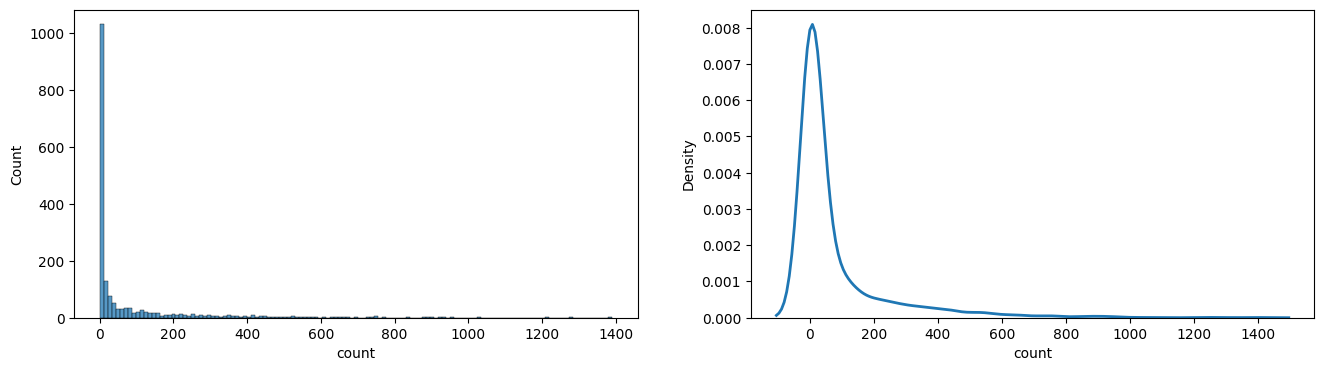

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(16,4), dpi=100)
sns.histplot(data=counts, ax=ax[0])
sns.kdeplot(counts, ax=ax[1], linewidth=2)
plt.show()

Fix some of typos with removing incorrect spaces

In [19]:
# before check
print("Before space fixes:", counts.shape)

# normalize spaces in names
df = name_fix.normalize_name_spaces(df)

# re-calculate unique names
counts = name_fix.get_unique_names(df)
print("After  space fixes:", counts.shape)

Before space fixes: (1809,)
After  space fixes: (1733,)


Count players with low plays (can be sign of type)

In [20]:
rare_under_20 = name_fix.get_rare_names(df)
print(rare_under_20.shape[0], 'of', counts.shape[0])

1068 of 1733


fact: output model will be more reasonable for high-lvl players

Convert winner column to a is-player-one-win column

In [21]:
df = clean.add_is_winner_column(df)
df.Winner.mean()

np.float64(0.5000219532542041)

### Phase 04 : ELO generation

Calculate ELO for players

In [22]:
df = elo.add_general_Elo(df)

In [23]:
df[['Elo_1', 'Elo_2', 'N_1', 'N_2', 'Elo_diff', 'Elo_mean', 'N_min']].describe()

,Elo_1,Elo_2,N_1,N_2,Elo_diff,Elo_mean,N_min
count,68327.000000,68327.000000,68327.000000,68327.000000,68327.000000,68327.000000,68327.000000
mean,1715.125629,1715.582613,198.553954,199.710437,-0.456984,1715.354121,107.712368
std,181.362618,181.914555,205.149535,207.247854,211.495782,147.682212,120.594273
min,1186.133989,1157.849669,0.000000,0.000000,-984.699299,1259.028608,0.000000
25%,1588.508686,1588.472150,47.000000,47.000000,-139.210306,1613.266796,22.000000
50%,1705.113366,1705.483249,132.000000,133.000000,-0.453565,1705.542270,67.000000
75%,1820.351543,1820.596826,285.000000,285.000000,137.419921,1805.016362,151.000000
max,2417.499705,2418.784407,1398.000000,1399.000000,915.665723,2333.125608,1099.000000


Calculate a surface bassed ELO for players

In [24]:
df = elo.add_surface_Elo(df)

In [25]:
df[['elo_surface_diff', 'elo_effective_diff', 'elo_prob', 'spec_diff', 'surface_exp_min']].describe()

,elo_surface_diff,elo_effective_diff,elo_prob,spec_diff,surface_exp_min
count,68327.000000,68327.000000,68327.000000,68327.000000,68327.000000
mean,0.077459,-0.011639,0.499995,0.000122,47.764646
std,102.982592,100.513745,0.131548,0.521689,61.738136
min,-517.347994,-497.949833,0.053838,-2.817756,0.000000
25%,-60.771562,-57.349511,0.418209,-0.306701,7.000000
50%,0.019295,0.096745,0.500139,-0.000047,25.000000
75%,61.159410,57.489306,0.581987,0.307578,64.000000
max,442.267955,443.516824,0.927781,2.498466,636.000000


### Phase 05 : remove player names

Calculate difference of `log1p` of pts for each players

In [26]:
df = feature. add_log_pts_diff(df)
df = feature.add_log_rank_diff(df)

Encode `Best of` and `Surface` as simple categorical data

In [27]:
df = feature.encode_best_of(df)
df = feature.encode_surface_types(df)

Result:

In [28]:
df.columns

Index(['Surface', 'Best of', 'Player_1', 'Player_2', 'Winner', 'Rank_1',
       'Rank_2', 'Pts_1', 'Pts_2', 'Elo_1', 'Elo_2', 'N_1', 'N_2', 'Elo_diff',
       'Elo_mean', 'N_min', 'elo_surface_diff', 'elo_effective_diff',
       'elo_prob', 'spec_diff', 'surface_exp_min', 'log_pts_diff',
       'log_rank_diff', 'Best_of_5', 'Surface_Clay', 'Surface_Grass',
       'Surface_Hard'],
      dtype='object')

### Phase 06 : finalize result

In [29]:
df_processed = df[[
    # overall ELO and experience
    'Elo_diff',
    'Elo_mean',
    'N_min', 

    # surface (as ELO form for each Player)
    'elo_surface_diff', 
    'elo_effective_diff', 
    'spec_diff', 
    'surface_exp_min', 

    # pts and rank
    'log_pts_diff', 
    'log_rank_diff', 

    # surface (as categorical data for each Game)
    'Surface_Clay', 
    'Surface_Grass', 
    'Surface_Hard', 

    # best of 3 or 5
    'Best_of_5'
]]

elo_prob_inedex = df[['elo_prob']]

In [30]:
df_processed.head()

,Elo_diff,Elo_mean,N_min,elo_surface_diff,elo_effective_diff,spec_diff,surface_exp_min,log_pts_diff,log_rank_diff,Surface_Clay,Surface_Grass,Surface_Hard,Best_of_5
0,0.0,1500.0,0.0,0.0,0.0,0.0,0,NaN,0.585902,0.0,0.0,1.0,0
66,0.0,1500.0,0.0,0.0,0.0,0.0,0,NaN,0.659246,0.0,0.0,1.0,0
65,0.0,1500.0,0.0,0.0,0.0,0.0,0,NaN,-0.037041,0.0,0.0,1.0,0
64,0.0,1500.0,0.0,0.0,0.0,0.0,0,NaN,0.843429,0.0,0.0,1.0,0
63,0.0,1500.0,0.0,0.0,0.0,0.0,0,NaN,-1.749200,0.0,0.0,1.0,0


In [31]:
df_processed.describe()

,Elo_diff,Elo_mean,N_min,elo_surface_diff,elo_effective_diff,spec_diff,surface_exp_min,log_pts_diff,log_rank_diff,Surface_Clay,Surface_Grass,Surface_Hard,Best_of_5
count,68327.000000,68327.000000,68327.000000,68327.000000,68327.000000,68327.000000,68327.000000,52700.000000,68327.000000,68327.000000,68327.000000,68327.000000,68327.000000
mean,-0.456984,1715.354121,107.712368,0.077459,-0.011639,0.000122,47.764646,-0.005264,0.001288,0.324089,0.137003,0.538908,0.189457
std,211.495782,147.682212,120.594273,102.982592,100.513745,0.521689,61.738136,1.187574,1.416994,0.468037,0.343853,0.498487,0.391874
min,-984.699299,1259.028608,0.000000,-517.347994,-497.949833,-2.817756,0.000000,-7.786635,-6.890813,0.000000,0.000000,0.000000,0.000000
25%,-139.210306,1613.266796,22.000000,-60.771562,-57.349511,-0.306701,7.000000,-0.714122,-0.910560,0.000000,0.000000,0.000000,0.000000
50%,-0.453565,1705.542270,67.000000,0.019295,0.096745,-0.000047,25.000000,-0.007749,0.013606,0.000000,0.000000,1.000000,0.000000
75%,137.419921,1805.016362,151.000000,61.159410,57.489306,0.307578,64.000000,0.699398,0.912510,1.000000,0.000000,1.000000,0.000000
max,915.665723,2333.125608,1099.000000,442.267955,443.516824,2.498466,636.000000,6.890813,6.530148,1.000000,1.000000,1.000000,1.000000


In [32]:
elo_prob_inedex.head()

,elo_prob
0,0.5
66,0.5
65,0.5
64,0.5
63,0.5


In [33]:
elo_prob_inedex.describe()

,elo_prob
count,68327.000000
mean,0.499995
std,0.131548
min,0.053838
25%,0.418209
50%,0.500139
75%,0.581987
max,0.927781


### Phase 07 : make different profiles